# RNN temporal analysis

Experimento de forecasting (predição) por meio de RNNs.

* Atividade PEL219 - GLWT MNIST - Gabriel Melo. Matrícula: 125.304-6

In [1]:
import numpy as np
import kagglehub
import pandas as pd

from matplotlib import pyplot as plt
from tensorflow.keras.layers import Dense, LSTM, InputLayer, Dropout, GRU
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential


from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1772993604.419781    4743 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1772993604.459817    4743 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1772993605.199983    4743 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off error

# Preparing data

In [2]:
# Download the forecasting dataset
path = kagglehub.dataset_download("arashnic/time-series-forecasting-with-yahoo-stock-price")
df = pd.read_csv(path + "/yahoo_stock.csv")
df

100%|██████████| 33.1k/33.1k [00:00<00:00, 434kB/s]

Extracting files...


,Date,High,Low,Open,Close,Volume,Adj Close
0,2015-11-23,2095.610107,2081.389893,2089.409912,2086.590088,3.587980e+09,2086.590088
1,2015-11-24,2094.120117,2070.290039,2084.419922,2089.139893,3.884930e+09,2089.139893
2,2015-11-25,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
3,2015-11-26,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
4,2015-11-27,2093.290039,2084.129883,2088.820068,2090.110107,1.466840e+09,2090.110107
...,...,...,...,...,...,...,...
1820,2020-11-16,3628.510010,3600.159912,3600.159912,3626.909912,5.281980e+09,3626.909912
1821,2020-11-17,3623.110107,3588.679932,3610.310059,3609.530029,4.799570e+09,3609.530029
1822,2020-11-18,3619.090088,3567.330078,3612.090088,3567.790039,5.274450e+09,3567.790039
1823,2020-11-19,3585.219971,3543.840088,3559.409912,3581.870117,4.347200e+09,3581.870117


In [3]:
def train_glwt(model: Sequential, X: np.array, Y: np.array, optimizer, loss, _epochs=10, _callbacks=[]):
    histories = []
    
    for i in range(1, len(model.layers)):
        for layer in model.layers[:i]:
            layer.trainable = False
        for layer in model.layers[i:]:
            layer.trainable = True

        model.compile(optimizer, loss, metrics=["mae"])
        
        histories.append(model.fit(x=X, y=Y, epochs=_epochs, validation_split=.1, callbacks=_callbacks))
            
    return histories

In [4]:
def create_sequences(data: np.array, seq_len: int = 5, forecast_len: int = 5):
    """
    create sequence of a original 1d series using a sliding window
    """
    X, y = [], []
    for i in range(len(data) - (seq_len + forecast_len)):
        seek = i+seq_len
        X.append(data[i:seek])
        y.append(data[seek:seek+forecast_len])
    return np.array(X), np.array(y)

In [5]:
values = df["Close"].values

scaler = MinMaxScaler(feature_range=(0, 1))

X, y = create_sequences(values)

X = scaler.fit_transform(X)
y = scaler.transform(y)

X.shape, y.shape

((1815, 5), (1815, 5))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=.3)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1270, 5, 1), (1270, 5), (545, 5, 1), (545, 5))

# Forecasting with LSTM

In [19]:
model = Sequential()
model.add(InputLayer((5, 1)))
model.add(LSTM(64, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(48, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(16))
model.add(Dense(5))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 5, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 48)             │        21,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,461 (154.14 KB)

 Trainable params: 39,461 (154.14 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)

histories = train_glwt(model, X_train, y_train, "adam", "mse", _epochs=100, _callbacks=[es])

for layer in model.layers:
    layer.trainable = True

model.compile("adam", "mse", metrics=["mae"])
model.fit(x=X_train, y=y_train, epochs=100, validation_split=.1, callbacks=[es])

Epoch 1/100


36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0631 - mae: 0.1969 - val_loss: 0.0042 - val_mae: 0.0583
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0085 - mae: 0.0750 - val_loss: 0.0033 - val_mae: 0.0505
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0046 - mae: 0.0536 - val_loss: 0.0025 - val_mae: 0.0447
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0030 - mae: 0.0411 - val_loss: 7.1627e-04 - val_mae: 0.0208
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0025 - mae: 0.0368 - val_loss: 7.9311e-04 - val_mae: 0.0230
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0023 - mae: 0.0352 - val_loss: 5.2992e-04 - val_mae: 0.0182
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0021 - mae: 0.0334 - val_loss: 5.6771e-04 - val_mae: 0.0188
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0019 - mae: 0.0318 - val_loss: 4.5846e-04 - val_mae: 0.0167
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - lo

## Testing

In [9]:
results = model.predict(X_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [10]:
mae = mean_absolute_error(y_test, results)
mse = mean_squared_error(y_test, results)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - results) / y_test)) * 100  # MAPE is in percentage
r2 = r2_score(y_test, results)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")
print(f"R2: {r2}")

MAE: 0.03520663356846221
MSE: 0.002357190198914617
RMSE: 0.04855090317300613
MAPE: 5.4612801311750685
R2: 0.8789849921944167


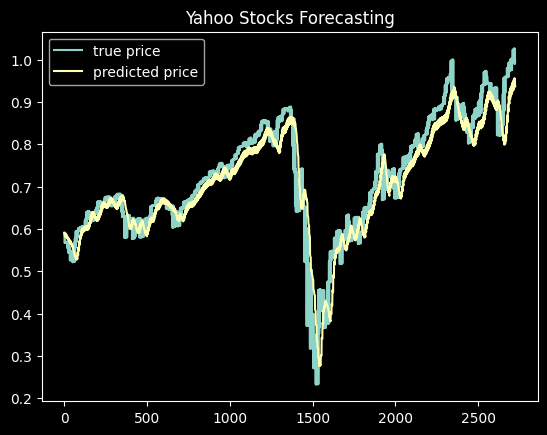

In [11]:
fig = plt.subplot(1,1,1)
fig.plot(y_test.flatten(), label="true price")
fig.plot(results.flatten(), label="predicted price")    
        
plt.title("Yahoo Stocks Forecasting")
plt.legend()

plt.show()

## Training data

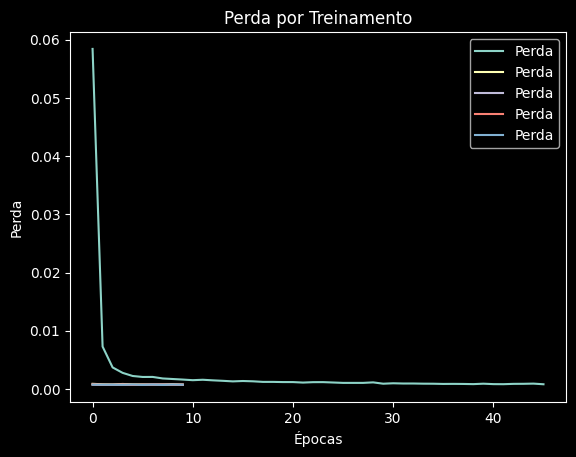

In [12]:
fig = plt.subplot(1,1,1)

for hist in histories:
    fig.plot(hist.history['loss'], label=f'Perda')
        
plt.title("Perda por Treinamento")
plt.xlabel("Épocas")
plt.ylabel("Perda")
plt.legend()

plt.show()

# Forecasting with GRU

In [13]:
model = Sequential()
model.add(InputLayer((5, 1)))
model.add(GRU(64, return_sequences=True))
model.add(Dropout(0.2))
model.add(GRU(48, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(16))
model.add(Dense(5))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 5, 64)          │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 48)             │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,149 (117.77 KB)

 Trainable params: 30,149 (117.77 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)

histories = train_glwt(model, X_train, y_train, "adam", "mse", _epochs=100, _callbacks=[es])

for layer in model.layers:
    layer.trainable = True

model.compile("adam", "mse", metrics=["mae"])
model.fit(x=X_train, y=y_train, epochs=100, validation_split=.1, callbacks=[es])

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0331 - mae: 0.1349 - val_loss: 0.0138 - val_mae: 0.1126
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0058 - mae: 0.0606 - val_loss: 0.0034 - val_mae: 0.0548
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0033 - mae: 0.0440 - val_loss: 4.9043e-04 - val_mae: 0.0181
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0026 - mae: 0.0376 - val_loss: 0.0010 - val_mae: 0.0287
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0024 - mae: 0.0359 - val_loss: 8.0460e-04 - val_mae: 0.0250
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0022 - mae: 0.0342 - val_loss: 3.1852e-04 - val_mae: 0.0139
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0020 - mae: 0.0330 - val_loss: 3.8554e-04 - val_mae: 0.0162
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0017 - mae: 0.0304 - val_loss: 5.3408e-04 - val_mae: 0.0193
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7

## Testing

In [15]:
results = model.predict(X_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [16]:
mae = mean_absolute_error(y_test, results)
mse = mean_squared_error(y_test, results)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - results) / y_test)) * 100  # MAPE is in percentage
r2 = r2_score(y_test, results)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")
print(f"R2: {r2}")

MAE: 0.037592820503249406
MSE: 0.0024475218179071147
RMSE: 0.049472434930040735
MAPE: 5.679380757397403
R2: 0.8743195361292238


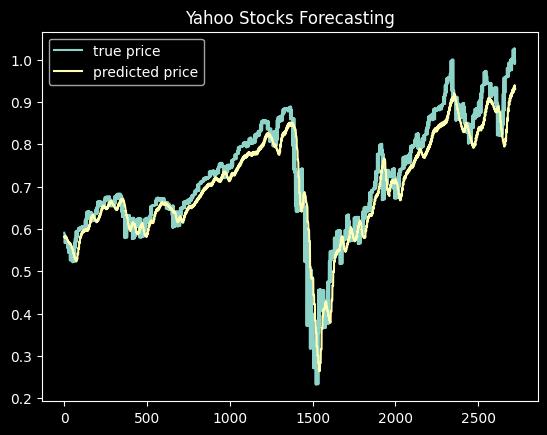

In [17]:
fig = plt.subplot(1,1,1)
fig.plot(y_test.flatten(), label="true price")
fig.plot(results.flatten(), label="predicted price")    
        
plt.title("Yahoo Stocks Forecasting")
plt.legend()

plt.show()

## Training data

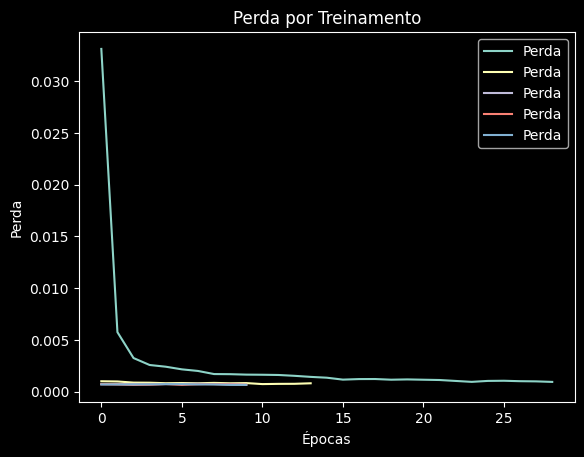

In [18]:
fig = plt.subplot(1,1,1)

for hist in histories:
    fig.plot(hist.history['loss'], label=f'Perda')
        
plt.title("Perda por Treinamento")
plt.xlabel("Épocas")
plt.ylabel("Perda")
plt.legend()

plt.show()